# EDA and data-quality report: Breakfast at the Frat

Weekly product-store sales for four categories (bag snacks, cold cereal, frozen pizza, oral hygiene).
This notebook documents what was checked, what was found and how each issue is handled in the modelling pipeline.
Run it from the `notebooks/` folder after placing the workbook in `data/raw/` (see the README).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

from src.utils import load_config
from src.data_loading import load_tables, prepare_lookups, merge_tables
from src.quality_checks import run as run_quality
from src.panel import build_panel
from src.features import build_panel_features
from src.elasticity import promo_lift

cfg = load_config()
tables = load_tables(cfg)
products, stores = prepare_lookups(tables["products"], tables["stores"])
tables["products"], tables["stores"] = products, stores
tx = tables["transactions"]
print({k: v.shape for k, v in tables.items()})

07:07:02 | data_loading | Loading cached tables from /home/claude/frat_forecasting/data/processed


{'transactions': (524950, 12), 'products': (58, 8), 'stores': (77, 9)}


## 1. Structure and joins

In [2]:
print("Weeks:", tx.week_end_date.nunique(), tx.week_end_date.min().date(), "to", tx.week_end_date.max().date())
print("Week spacing (days):", tx.week_end_date.drop_duplicates().sort_values().diff().dt.days.value_counts().to_dict())
print("Stores:", tx.store_num.nunique(), "| UPCs in transactions:", tx.upc.nunique(), "| UPCs in lookup:", products.upc.nunique())
print("Stores with conflicting tier labels in the lookup:", stores.attrs.get("tier_conflict_stores"))
display(products.groupby(["category", "sub_category"]).size().rename("upcs").reset_index())
display(stores.seg_value_name.value_counts().rename("stores").to_frame().T)
display(stores.address_state_prov_code.value_counts().rename("stores").to_frame().T)

Weeks: 156 2009-01-14 to 2012-01-04
Week spacing (days): {7.0: 155}
Stores: 77 | UPCs in transactions: 55 | UPCs in lookup: 58
Stores with conflicting tier labels in the lookup: [4503, 17627]


,category,sub_category,upcs
0,BAG SNACKS,PRETZELS,15
1,COLD CEREAL,ADULT CEREAL,3
2,COLD CEREAL,ALL FAMILY CEREAL,7
3,COLD CEREAL,KIDS CEREAL,5
4,FROZEN PIZZA,PIZZA/PREMIUM,15
5,ORAL HYGIENE PRODUCTS,MOUTHWASH/RINSES AND SPRAYS,5
6,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),8


seg_value_name,Mainstream,Value,Upscale
stores,43,19,15


address_state_prov_code,TX,OH,KY,IN
stores,41,31,4,1


## 2. Data-quality summary

In [3]:
clean, report = run_quality(cfg, tables)
display(report)

07:07:04 | quality_checks | Data-quality summary written (21 checks); 18 rows excluded


,check,value,note
0,Rows,524950,
1,Weeks,156,2009-01-14 to 2012-01-04
2,Stores in transactions,77,
3,UPCs in transactions,55,58 in product lookup
4,Store-UPC series,3909,
5,Duplicate week-store-UPC rows,0,
6,UPCs missing from product lookup,0,
7,Stores missing from store lookup,0,
8,Stores with conflicting tier labels,2,"first label kept: 4503, 17627"
9,Missing price,23,refilled from the same series


## 3. Outliers

The user guide suggests units per visit and visits per household as outlier screens. Flagged rows are kept in
the data and reported separately, because they reflect real behaviour.

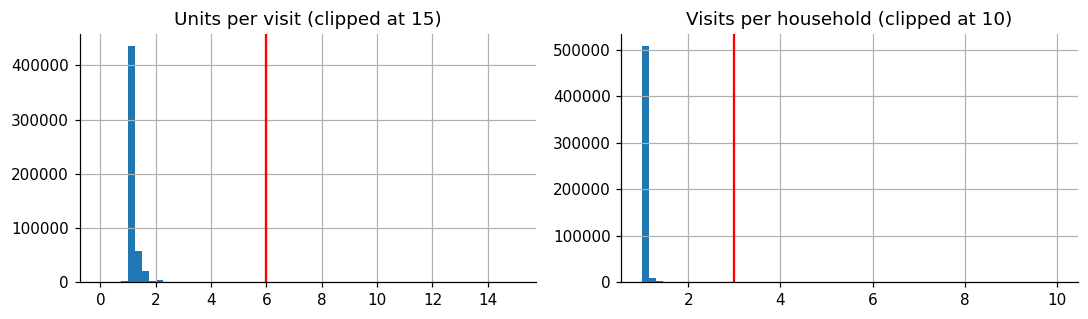

Rows flagged as outliers: 341 (0.06%)


,week_end_date,store_num,upc,units,visits,hhs,price
450043,2009-02-11,25027,1600027527,1800,1340,1286,1.64
451413,2010-08-11,25027,3000006560,1179,899,866,1.36
450045,2009-02-25,25027,1600027527,1136,860,824,1.64
450044,2009-02-18,25027,1600027527,1054,839,815,1.60
451540,2010-08-11,25027,3000006610,1017,755,732,1.32


In [4]:
d = clean.assign(upv=clean.units / clean.visits.replace(0, np.nan), vph=clean.visits / clean.hhs.replace(0, np.nan))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
d.upv.clip(upper=15).hist(bins=60, ax=ax[0]); ax[0].set_title("Units per visit (clipped at 15)"); ax[0].axvline(cfg["data"]["outlier_units_per_visit"], color="r")
d.vph.clip(upper=10).hist(bins=60, ax=ax[1]); ax[1].set_title("Visits per household (clipped at 10)"); ax[1].axvline(cfg["data"]["outlier_visits_per_hh"], color="r")
plt.tight_layout(); plt.show()
print("Rows flagged as outliers:", int(clean.flag_outlier.sum()), f"({clean.flag_outlier.mean():.2%})")
display(clean.nlargest(5, "units")[["week_end_date", "store_num", "upc", "units", "visits", "hhs", "price"]])

## 4. Panel completeness

A full panel would have one row per week for every store-UPC pair. The raw data is sparser, so the pipeline makes
each series contiguous between its first and last observed week and inserts missing weeks inside that span as zero
units (flagged `flag_inserted`). Weeks before the first or after the last observation are not created.

07:07:05 | panel | Panel: 575173 rows, 3909 series, 50223 inserted zero rows (8.7%)


,count
series,3909
full 156 weeks observed,1225
start after week 1,751
end before last week,582
series with interior gaps,2431
inserted zero rows,50223


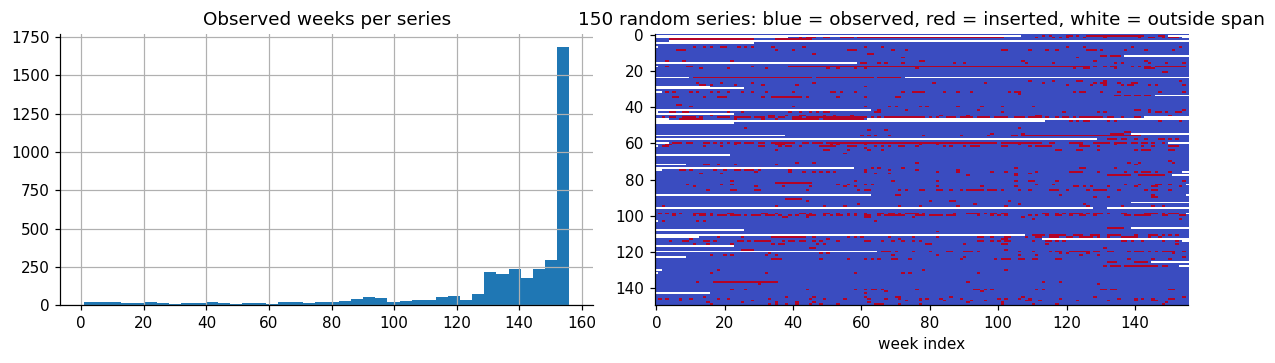

In [5]:
panel, week_map = build_panel(clean, cfg)
g = panel.groupby("series_id").agg(first=("week_idx", "min"), last=("week_idx", "max"), obs=("flag_inserted", lambda s: (s == 0).sum()), ins=("flag_inserted", "sum"))
n_weeks = panel.week_idx.max() + 1
summary = pd.Series({
    "series": len(g),
    "full 156 weeks observed": int((g.obs == n_weeks).sum()),
    "start after week 1": int((g["first"] > 0).sum()),
    "end before last week": int((g["last"] < n_weeks - 1).sum()),
    "series with interior gaps": int((g.ins > 0).sum()),
    "inserted zero rows": int(g.ins.sum()),
})
display(summary.to_frame("count"))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
g.obs.hist(bins=40, ax=ax[0]); ax[0].set_title("Observed weeks per series")
sample = panel[panel.series_id.isin(g.sample(150, random_state=1).index)].pivot(index="series_id", columns="week_idx", values="flag_inserted")
full = pd.DataFrame(np.nan, index=sample.index, columns=range(n_weeks)); full.update(sample)
ax[1].imshow(full.values, aspect="auto", cmap="coolwarm", interpolation="nearest"); ax[1].set_title("150 random series: blue = observed, red = inserted, white = outside span")
ax[1].set_xlabel("week index"); plt.tight_layout(); plt.show()

## 5. Demand over time

07:07:07 | features | Panel features built: 575173 rows x 52 columns


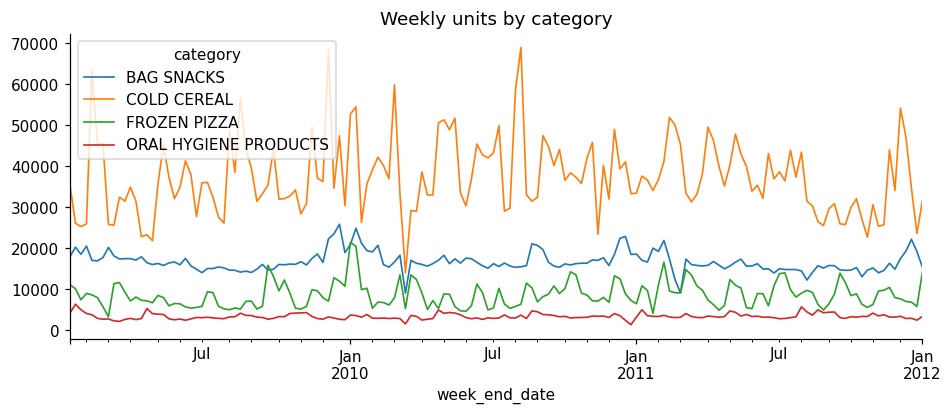

Mean weekly units per observed row, by calendar event week:
thanks  xmas  sb
0       0     0     19.66
              1     21.29
        1     0     17.72
1       0     0     17.26
Name: units_per_row, dtype: float64


In [6]:
pf = build_panel_features(panel, products, stores)
obs = pf[pf.flag_inserted == 0].assign(category=lambda x: x.category.astype(str))
t = obs.groupby(["week_end_date", "category"]).units.sum().unstack()
t.plot(figsize=(10, 3.6), lw=1.1, title="Weekly units by category"); plt.show()
hol = obs.groupby("week_end_date").agg(units=("units", "sum"), n=("units", "size"), thanks=("thanksgiving_week", "max"), xmas=("christmas_week", "max"), sb=("superbowl_week", "max"))
hol["units_per_row"] = hol.units / hol.n
print("Mean weekly units per observed row, by calendar event week:")
print(hol.groupby(["thanks", "xmas", "sb"]).units_per_row.mean().round(2))

## 6. Prices

Price range by category (min / median / max shelf price):


,min,50%,max
category,,,
BAG SNACKS,0.55,2.39,3.49
COLD CEREAL,0.58,2.72,7.00
FROZEN PIZZA,0.01,5.49,8.91
ORAL HYGIENE PRODUCTS,0.46,4.19,11.46


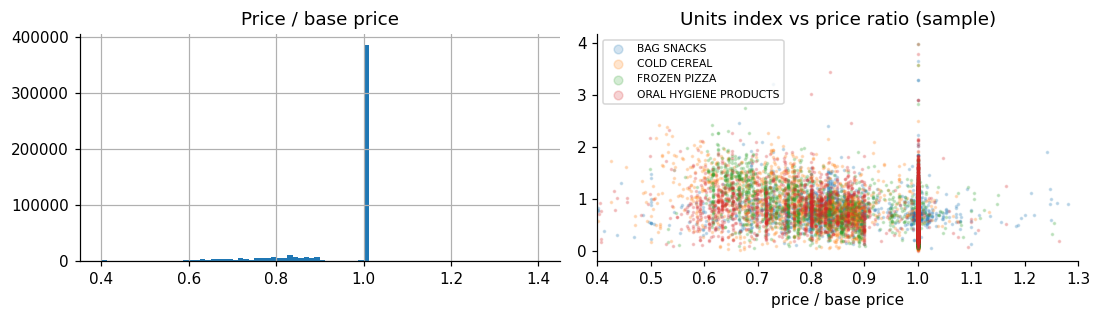

In [7]:
ratio = (obs.price / obs.base_price)
print("Price range by category (min / median / max shelf price):")
display(obs.groupby("category").price.describe()[["min", "50%", "max"]].round(2))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ratio.clip(0.4, 1.4).hist(bins=80, ax=ax[0]); ax[0].set_title("Price / base price")
smp = obs.sample(20000, random_state=0)
for c, gg in smp.groupby("category"):
    ax[1].scatter(gg.price / gg.base_price, np.log1p(gg.units / gg.o_mean52.replace(0, np.nan)), s=2, alpha=0.2, label=c)
ax[1].set_xlim(0.4, 1.3); ax[1].set_title("Units index vs price ratio (sample)"); ax[1].set_xlabel("price / base price"); ax[1].legend(markerscale=4, fontsize=7)
plt.tight_layout(); plt.show()

## 7. Promotions

The three promotion flags never overlap except feature + display, so promotions are encoded as five states:
none, TPR only, display only, feature only, feature + display. Lift is measured against each series' own
non-promoted weeks (median ratio), which controls for store and product size.

In [8]:
print(obs.assign(promo=obs.promo_type.map({0:"none",1:"TPR only",2:"display only",3:"feature only",4:"feature + display"})).promo.value_counts(normalize=True).round(3))
pl = promo_lift(pf)
display(pl[pl.split == "overall"].round(3))
display(pl[pl.split == "category"].pivot(index="segment", columns="promo", values="units_lift").round(2))

promo
none                 0.715
TPR only             0.135
display only         0.066
feature + display    0.045
feature only         0.040
Name: proportion, dtype: float64


,split,segment,promo,rows,units_lift,visits_lift,units_per_visit,avg_discount
0,overall,all,TPR only,70734,1.185,1.155,1.087,0.218
1,overall,all,display only,34388,1.545,1.534,1.083,0.123
2,overall,all,feature + display,23414,3.582,3.322,1.143,0.252
3,overall,all,feature only,20837,2.126,1.997,1.143,0.229
4,overall,all,none,375559,0.945,0.951,1.000,0.000


promo,TPR only,display only,feature + display,feature only,none
segment,,,,,
BAG SNACKS,1.08,1.38,2.74,1.65,0.94
COLD CEREAL,1.20,2.06,4.13,2.07,0.98
FROZEN PIZZA,1.36,2.24,3.44,2.33,0.92
ORAL HYGIENE PRODUCTS,1.25,1.36,2.76,2.10,0.89


## 8. Store segments

In [9]:
o = obs.assign(tier=obs.tier.astype(str), state=obs.state.astype(str))
display(o.groupby("tier").agg(stores=("store_num", "nunique"), avg_units_per_row=("units", "mean"), avg_price=("price", "mean"), promo_share=("promo_type", lambda s: (s > 0).mean())).round(2))
display(o.groupby("state").agg(stores=("store_num", "nunique"), avg_units_per_row=("units", "mean"), avg_price=("price", "mean")).round(2))
store_tot = o.groupby("store_num").agg(units=("units", "sum"), baskets=("avg_weekly_baskets", "first"))
print("Correlation between store total units and average weekly baskets:", round(store_tot.corr().iloc[0, 1], 3))

,stores,avg_units_per_row,avg_price,promo_share
tier,,,,
Mainstream,43,19.62,3.39,0.29
Upscale,15,23.57,3.46,0.27
Value,19,15.85,3.29,0.29


,stores,avg_units_per_row,avg_price
state,,,
IN,1,22.03,3.39
KY,4,23.83,3.35
OH,31,23.75,3.36
TX,41,15.53,3.41


Correlation between store total units and average weekly baskets: 0.696


## 9. Decisions carried into the pipeline

- Rows are flagged, not deleted; rows with zero units but positive visits are excluded from training and scoring.
- Missing or zero prices are refilled from neighbouring weeks of the same store-UPC series.
- Two stores have conflicting price-tier labels in the lookup; the first label is used.
- Missing weeks inside a series' active span are inserted as zero units and flagged; they are never scored.
- Outliers are kept, and headline metrics are reported with and without them.
- Promotions are modelled as five mutually exclusive states.